# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Load data

In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

FILE_NAME = "HistoricalFuelConsumption2023-2026.csv"

df = pd.read_csv(FILE_NAME)

print("=" * 70)
print("ORIGINAL DATA")
print("=" * 70)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

ORIGINAL DATA
Shape: (126, 17)

Columns:
['Periode', 'Kontraktor', 'ProdOB', 'HDOB', 'VDOB', 'ProdCM', 'HDCM', 'VDCM', 'ProdCH', 'HDCH', 'FuelForecastOB', 'FuelForecastCM', 'FuelForecastCH', 'FuelForecastOth', 'FuelForecastbyDMR', 'FuelSupplybyLog', 'FuelUsageAct']


# Feature Engineering

In [3]:
# ============================================================
# 2. CONVERT DATE
# ============================================================

df["Periode"] = pd.to_datetime(
    df["Periode"],
    errors="coerce"
)

print("\nInvalid dates:", df["Periode"].isna().sum())

# Remove rows with invalid dates
df = df.dropna(subset=["Periode"])


# ============================================================
# 3. SORT DATA
# ============================================================

df = df.sort_values(
    ["Periode", "Kontraktor"]
).reset_index(drop=True)


# ============================================================
# 4. ORIGINAL FEATURES
# ============================================================

base_features = [
    "ProdOB",
    "HDOB",
    "VDOB",
    "ProdCM",
    "HDCM",
    "VDCM",
    "ProdCH",
    "HDCH",
    "FuelForecastOB",
    "FuelForecastCM",
    "FuelForecastCH",
    "FuelForecastOth",
    "FuelForecastbyDMR"
]

target_cols = [
    "FuelSupplybyLog",
    "FuelUsageAct"
]


# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES BEFORE PROCESSING")
print("=" * 70)

print(
    df[
        ["Kontraktor", "Periode"]
        + base_features
        + target_cols
    ].isna().sum()
)


# ============================================================
# 6. CALENDAR FEATURES
# ============================================================

df["Year"] = df["Periode"].dt.year
df["Month"] = df["Periode"].dt.month
df["Quarter"] = df["Periode"].dt.quarter

# Cyclical representation of month
df["Month_sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)


# ============================================================
# 7. CREATE LAG FEATURES
# ============================================================
#
# IMPORTANT:
# Lag features are calculated separately for each contractor.
#
# Example:
#
# SIS Jan -> previous SIS month
# SIS Feb -> previous SIS month
#
# BUMA Feb does NOT use SIS Jan.
# ============================================================

lag_targets = [
    "FuelSupplybyLog",
    "FuelUsageAct"
]

lag_periods = [1, 2, 3]

for target in lag_targets:

    for lag in lag_periods:

        df[f"{target}_lag{lag}"] = (
            df.groupby("Kontraktor")[target]
              .shift(lag)
        )


# ============================================================
# 8. CREATE ROLLING FEATURES
# ============================================================
#
# shift(1) is essential.
#
# Without shift(1), the current month's actual value would
# enter the rolling calculation and cause data leakage.
# ============================================================

for target in lag_targets:

    df[f"{target}_rolling3"] = (
        df.groupby("Kontraktor")[target]
          .transform(
              lambda x:
              x.shift(1).rolling(
                  window=3,
                  min_periods=1
              ).mean()
          )
    )

    df[f"{target}_rolling6"] = (
        df.groupby("Kontraktor")[target]
          .transform(
              lambda x:
              x.shift(1).rolling(
                  window=6,
                  min_periods=1
              ).mean()
          )
    )


# ============================================================
# 9. REMOVE ROWS WITHOUT ENOUGH HISTORY
# ============================================================
#
# Because lag3 is used, the first 3 observations of each
# contractor do not have a valid lag3.
# ============================================================

required_history_cols = [
    "FuelSupplybyLog_lag3",
    "FuelUsageAct_lag3"
]

before_history = len(df)

df = df.dropna(
    subset=required_history_cols
).reset_index(drop=True)

print(
    "\nRows removed because of insufficient history:",
    before_history - len(df)
)


# ============================================================
# 10. CREATE CONTRACTOR DUMMIES
# ============================================================

df = pd.get_dummies(
    df,
    columns=["Kontraktor"],
    drop_first=False,
    dtype=int
)

contractor_cols = [
    col
    for col in df.columns
    if col.startswith("Kontraktor_")
]


# ============================================================
# 11. DEFINE FINAL FEATURES
# ============================================================

calendar_features = [
    "Year",
    "Month",
    "Quarter",
    "Month_sin",
    "Month_cos"
]

lag_features = []

for target in lag_targets:

    for lag in lag_periods:
        lag_features.append(
            f"{target}_lag{lag}"
        )

    lag_features.append(
        f"{target}_rolling3"
    )

    lag_features.append(
        f"{target}_rolling6"
    )


feature_cols = (
    calendar_features
    + base_features
    + lag_features
    + contractor_cols
)


print("\n" + "=" * 70)
print("FINAL FEATURES")
print("=" * 70)

print("Number of features:", len(feature_cols))

for feature in feature_cols:
    print("-", feature)


# ============================================================
# 12. CHECK FINAL DATA
# ============================================================

print("\nFinal dataset shape:", df.shape)

print("\nMissing values:")
print(
    df[
        feature_cols + target_cols
    ].isna().sum()
)


Invalid dates: 0

MISSING VALUES BEFORE PROCESSING
Kontraktor            0
Periode               0
ProdOB                0
HDOB                  0
VDOB                  0
ProdCM                0
HDCM                  0
VDCM                  0
ProdCH               84
HDCH                 84
FuelForecastOB        0
FuelForecastCM        0
FuelForecastCH       84
FuelForecastOth       0
FuelForecastbyDMR     0
FuelSupplybyLog       0
FuelUsageAct          0
dtype: int64

Rows removed because of insufficient history: 9

FINAL FEATURES
Number of features: 31
- Year
- Month
- Quarter
- Month_sin
- Month_cos
- ProdOB
- HDOB
- VDOB
- ProdCM
- HDCM
- VDCM
- ProdCH
- HDCH
- FuelForecastOB
- FuelForecastCM
- FuelForecastCH
- FuelForecastOth
- FuelForecastbyDMR
- FuelSupplybyLog_lag1
- FuelSupplybyLog_lag2
- FuelSupplybyLog_lag3
- FuelSupplybyLog_rolling3
- FuelSupplybyLog_rolling6
- FuelUsageAct_lag1
- FuelUsageAct_lag2
- FuelUsageAct_lag3
- FuelUsageAct_rolling3
- FuelUsageAct_rolling6
- Kontra

# Data splitting

In [4]:
# ============================================================
# 13. TIME-BASED TRAIN / TEST SPLIT
# ============================================================
#
# Use 80% of the unique months for training.
#
# This avoids randomly mixing future and historical data.
# ============================================================

unique_dates = sorted(
    df["Periode"].unique()
)

split_date_index = int(
    len(unique_dates) * 0.80
)

if split_date_index <= 0:
    raise ValueError(
        "Not enough dates for training."
    )

if split_date_index >= len(unique_dates):
    raise ValueError(
        "Test set would contain zero dates."
    )

split_date = unique_dates[split_date_index]


train = df[
    df["Periode"] < split_date
].copy()

test = df[
    df["Periode"] >= split_date
].copy()


print("\n" + "=" * 70)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 70)

print(
    "Split date:",
    pd.Timestamp(split_date)
)

print(
    "Training:",
    train["Periode"].min(),
    "to",
    train["Periode"].max()
)

print(
    "Testing :",
    test["Periode"].min(),
    "to",
    test["Periode"].max()
)

print("\nTraining samples:", len(train))
print("Testing samples :", len(test))


TIME-BASED TRAIN / TEST SPLIT
Split date: 2025-11-01 00:00:00
Training: 2023-04-01 00:00:00 to 2025-10-01 00:00:00
Testing : 2025-11-01 00:00:00 to 2026-06-01 00:00:00

Training samples: 93
Testing samples : 24


# Modeling

In [5]:
# ============================================================
# 14. PREPARE X AND y
# ============================================================

X_train = train[feature_cols].copy()
X_test = test[feature_cols].copy()

y_train = train[target_cols].copy()
y_test = test[target_cols].copy()


# ============================================================
# 15. HANDLE MISSING FEATURE VALUES
# ============================================================
#
# IMPORTANT:
# Median values are calculated ONLY from training data.
#
# This prevents information from the test period leaking into
# the training process.
# ============================================================

numeric_feature_cols = [
    col
    for col in feature_cols
    if X_train[col].dtype != "bool"
]

for col in numeric_feature_cols:

    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(
        median_value
    )

    X_test[col] = X_test[col].fillna(
        median_value
    )


# Handle boolean columns if any
for col in feature_cols:

    if X_train[col].dtype == "bool":

        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)


# Final safety check
if X_train.isna().sum().sum() > 0:
    raise ValueError(
        "Missing values still exist in X_train."
    )

if X_test.isna().sum().sum() > 0:
    raise ValueError(
        "Missing values still exist in X_test."
    )


# ============================================================
# 16. METRIC FUNCTIONS
# ============================================================

def smape(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2

    # Avoid division by zero
    mask = denominator != 0

    return (
        np.mean(
            np.abs(
                y_true[mask] -
                y_pred[mask]
            ) / denominator[mask]
        ) * 100
    )


def calculate_metrics(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    smape_value = smape(
        y_true,
        y_pred
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "sMAPE": smape_value,
        "R2": r2
    }

In [6]:
# ============================================================
# 17. TRAIN RANDOM FOREST MODELS
# ============================================================
#
# Separate model for each target.
# ============================================================

models = {}
predictions = {}

for target in target_cols:

    print("\n" + "=" * 70)
    print(f"TRAINING MODEL: {target}")
    print("=" * 70)

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=1
    )

    model.fit(
        X_train,
        y_train[target]
    )

    prediction = model.predict(
        X_test
    )

    models[target] = model
    predictions[target] = prediction


# ============================================================
# 18. RANDOM FOREST PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

results = []

for target in target_cols:

    metrics = calculate_metrics(
        y_test[target],
        predictions[target]
    )

    results.append(
        {
            "Target": target,
            "Model": "Random Forest",
            **metrics
        }
    )

    print(f"\n--- {target} ---")

    print(
        f"MSE   : {metrics['MSE']:,.2f}"
    )

    print(
        f"RMSE  : {metrics['RMSE']:,.2f}"
    )

    print(
        f"MAE   : {metrics['MAE']:,.2f}"
    )

    print(
        f"sMAPE : {metrics['sMAPE']:.2f}%"
    )

    print(
        f"R²    : {metrics['R2']:.4f}"
    )


TRAINING MODEL: FuelSupplybyLog

TRAINING MODEL: FuelUsageAct

RANDOM FOREST RESULTS

--- FuelSupplybyLog ---
MSE   : 1,471,668,826,587.72
RMSE  : 1,213,123.58
MAE   : 820,371.84
sMAPE : 6.97%
R²    : 0.9892

--- FuelUsageAct ---
MSE   : 1,423,390,156,234.13
RMSE  : 1,193,059.16
MAE   : 792,394.07
sMAPE : 6.59%
R²    : 0.9894


# Prediction

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# 14. Evaluate Predictions
# ============================================================
# Note: Using 'predictions' dictionary created during training

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

# Scikit-learn doesn't have a direct root_mean_squared_error in older versions,
# but we can use squared=False in mean_squared_error

for target in target_cols:
    actual = y_test[target].values
    predicted = predictions[target]

    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    smape_val = smape(actual, predicted)

    print(f"\n--- {target} ---")
    print(f"MSE   : {mse:,.2f}")
    print(f"RMSE  : {rmse:,.2f}")
    print(f"MAE   : {mae:,.2f}")
    print(f"sMAPE : {smape_val:.2f}%")


--- FuelSupplybyLog ---
MSE   : 1,471,668,826,587.72
RMSE  : 1,213,123.58
MAE   : 820,371.84
sMAPE : 6.97%

--- FuelUsageAct ---
MSE   : 1,423,390,156,234.13
RMSE  : 1,193,059.16
MAE   : 792,394.07
sMAPE : 6.59%


# Naive Bayes (for comparison)

In [9]:
# ============================================================
# 19. NAÏVE BASELINE
# ============================================================
#
# The naïve forecast says:
#
# "Next month's value = previous month's actual value."
#
# This is an important benchmark for time-series forecasting.
#
# The lag1 values were already calculated before the split,
# so test-period predictions use only previous observations.
# ============================================================

print("\n" + "=" * 70)
print("NAÏVE BASELINE RESULTS")
print("=" * 70)

for target in target_cols:

    baseline_prediction = test[
        f"{target}_lag1"
    ].values

    metrics = calculate_metrics(
        y_test[target],
        baseline_prediction
    )

    results.append(
        {
            "Target": target,
            "Model": "Naive Previous Month",
            **metrics
        }
    )

    print(f"\n--- {target} ---")

    print(
        f"MSE   : {metrics['MSE']:,.2f}"
    )

    print(
        f"RMSE  : {metrics['RMSE']:,.2f}"
    )

    print(
        f"MAE   : {metrics['MAE']:,.2f}"
    )

    print(
        f"sMAPE : {metrics['sMAPE']:.2f}%"
    )

    print(
        f"R²    : {metrics['R2']:.4f}"
    )


NAÏVE BASELINE RESULTS

--- FuelSupplybyLog ---
MSE   : 1,570,504,745,446.79
RMSE  : 1,253,197.81
MAE   : 952,436.29
sMAPE : 8.13%
R²    : 0.9885

--- FuelUsageAct ---
MSE   : 1,647,916,626,085.00
RMSE  : 1,283,712.05
MAE   : 966,581.58
sMAPE : 8.28%
R²    : 0.9878


# Result

In [10]:
# ============================================================
# 20. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:,.4f}"
    )
)


# ============================================================
# 21. DETERMINE WHETHER RANDOM FOREST BEATS NAÏVE MODEL
# ============================================================

print("\n" + "=" * 70)
print("MODEL INTERPRETATION")
print("=" * 70)

for target in target_cols:

    rf_row = results_df[
        (results_df["Target"] == target) &
        (results_df["Model"] == "Random Forest")
    ].iloc[0]

    naive_row = results_df[
        (results_df["Target"] == target) &
        (results_df["Model"] == "Naive Previous Month")
    ].iloc[0]

    rmse_improvement = (
        (
            naive_row["RMSE"] -
            rf_row["RMSE"]
        )
        /
        naive_row["RMSE"]
    ) * 100

    mae_improvement = (
        (
            naive_row["MAE"] -
            rf_row["MAE"]
        )
        /
        naive_row["MAE"]
    ) * 100

    print(f"\n{target}")

    print(
        f"RMSE improvement: "
        f"{rmse_improvement:.2f}%"
    )

    print(
        f"MAE improvement : "
        f"{mae_improvement:.2f}%"
    )

    if rmse_improvement > 0:

        print(
            "Conclusion: Random Forest "
            "has lower RMSE than the naïve model."
        )

    else:

        print(
            "Conclusion: Random Forest "
            "does NOT beat the naïve model on RMSE."
        )


# ============================================================
# 22. PREDICTION TABLE
# ============================================================

prediction_df = test[
    [
        "Periode"
    ]
    + contractor_cols
].copy()

for target in target_cols:

    prediction_df[
        f"{target}_Actual"
    ] = y_test[target].values

    prediction_df[
        f"{target}_Predicted"
    ] = predictions[target]

    prediction_df[
        f"{target}_Error"
    ] = (
        prediction_df[
            f"{target}_Actual"
        ]
        -
        prediction_df[
            f"{target}_Predicted"
        ]
    )


print("\n" + "=" * 70)
print("PREDICTIONS")
print("=" * 70)

print(
    prediction_df.to_string(
        index=False
    )
)


MODEL COMPARISON
         Target                Model                    MSE           RMSE          MAE  sMAPE     R2
FuelSupplybyLog        Random Forest 1,471,668,826,587.7178 1,213,123.5826 820,371.8434 6.9696 0.9892
   FuelUsageAct        Random Forest 1,423,390,156,234.1270 1,193,059.1587 792,394.0694 6.5906 0.9894
FuelSupplybyLog Naive Previous Month 1,570,504,745,446.7917 1,253,197.8078 952,436.2917 8.1333 0.9885
   FuelUsageAct Naive Previous Month 1,647,916,626,085.0000 1,283,712.0495 966,581.5833 8.2781 0.9878

MODEL INTERPRETATION

FuelSupplybyLog
RMSE improvement: 3.20%
MAE improvement : 13.87%
Conclusion: Random Forest has lower RMSE than the naïve model.

FuelUsageAct
RMSE improvement: 7.06%
MAE improvement : 18.02%
Conclusion: Random Forest has lower RMSE than the naïve model.

PREDICTIONS
   Periode  Kontraktor_BUMA  Kontraktor_PPA  Kontraktor_SIS  FuelSupplybyLog_Actual  FuelSupplybyLog_Predicted  FuelSupplybyLog_Error  FuelUsageAct_Actual  FuelUsageAct_Predicted  Fu

# Performance by contractor

In [11]:
# ============================================================
# 23. PERFORMANCE BY CONTRACTOR
# ============================================================
#
# Convert dummy variables back into contractor information.
# ============================================================

contractor_name = None

for col in contractor_cols:

    if col in test.columns:

        if contractor_name is None:

            contractor_name = np.where(
                test[col] == 1,
                col.replace("Kontraktor_", ""),
                None
            )

        else:

            contractor_name = np.where(
                test[col] == 1,
                col.replace("Kontraktor_", ""),
                contractor_name
            )

test["ContractorName"] = contractor_name


print("\n" + "=" * 70)
print("PERFORMANCE BY CONTRACTOR")
print("=" * 70)

for target in target_cols:

    print(f"\n--- {target} ---")

    for contractor in sorted(
        test["ContractorName"].dropna().unique()
    ):

        mask = (
            test["ContractorName"]
            == contractor
        )

        actual = y_test.loc[
            mask,
            target
        ].values

        predicted = predictions[target][
            mask.values
        ]

        metrics = calculate_metrics(
            actual,
            predicted
        )

        print(
            f"\n{contractor}"
        )

        print(
            f"RMSE  : {metrics['RMSE']:,.2f}"
        )

        print(
            f"MAE   : {metrics['MAE']:,.2f}"
        )

        print(
            f"sMAPE : {metrics['sMAPE']:.2f}%"
        )

        print(
            f"R²    : {metrics['R2']:.4f}"
        )


PERFORMANCE BY CONTRACTOR

--- FuelSupplybyLog ---

BUMA
RMSE  : 885,557.11
MAE   : 596,032.34
sMAPE : 5.93%
R²    : -0.4318

PPA
RMSE  : 516,679.25
MAE   : 409,661.18
sMAPE : 10.27%
R²    : -1.2653

SIS
RMSE  : 1,834,076.78
MAE   : 1,455,422.01
sMAPE : 4.71%
R²    : 0.0472

--- FuelUsageAct ---

BUMA
RMSE  : 755,638.23
MAE   : 475,084.21
sMAPE : 4.74%
R²    : -0.1818

PPA
RMSE  : 508,991.72
MAE   : 406,645.95
sMAPE : 10.16%
R²    : -1.2722

SIS
RMSE  : 1,854,753.02
MAE   : 1,495,452.05
sMAPE : 4.87%
R²    : 0.0927


# Feature importance


FEATURE IMPORTANCE

--- FuelSupplybyLog ---
                 Feature  Importance
FuelSupplybyLog_rolling3    0.084361
    FuelSupplybyLog_lag2    0.081491
    FuelSupplybyLog_lag3    0.073218
       FuelUsageAct_lag2    0.068764
    FuelSupplybyLog_lag1    0.067286
   FuelUsageAct_rolling3    0.064382
       FuelUsageAct_lag1    0.061744
FuelSupplybyLog_rolling6    0.060671
   FuelUsageAct_rolling6    0.060464
       FuelForecastbyDMR    0.059810
          FuelForecastCM    0.056216
          Kontraktor_SIS    0.052335
       FuelUsageAct_lag3    0.051661
                  ProdCM    0.045728
          FuelForecastOB    0.032734


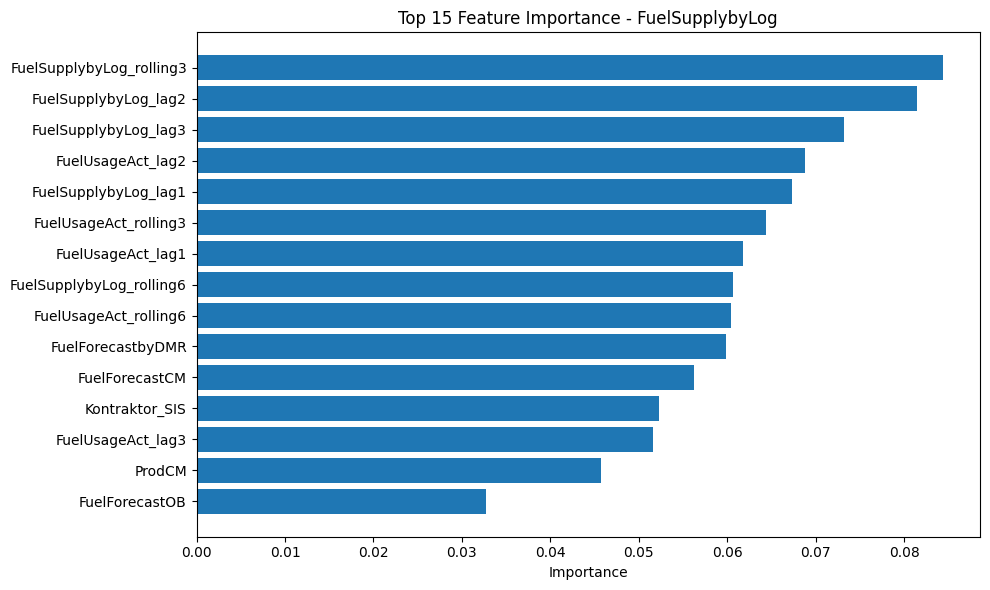


--- FuelUsageAct ---
                 Feature  Importance
FuelSupplybyLog_rolling3    0.083886
    FuelSupplybyLog_lag2    0.080885
    FuelSupplybyLog_lag3    0.073766
       FuelUsageAct_lag2    0.067965
    FuelSupplybyLog_lag1    0.067197
   FuelUsageAct_rolling3    0.064074
       FuelUsageAct_lag1    0.061915
FuelSupplybyLog_rolling6    0.060759
       FuelForecastbyDMR    0.060229
   FuelUsageAct_rolling6    0.059723
          FuelForecastCM    0.055756
          Kontraktor_SIS    0.052267
       FuelUsageAct_lag3    0.051584
                  ProdCM    0.045160
          FuelForecastOB    0.033001


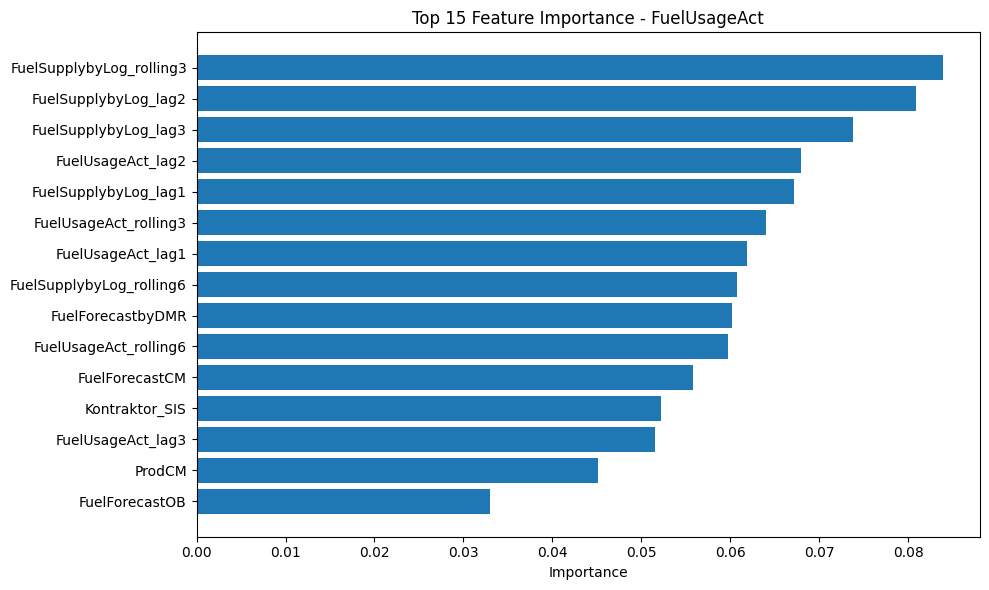

In [12]:
# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

for target in target_cols:

    model = models[target]

    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(f"\n--- {target} ---")

    print(
        importance_df.head(15).to_string(
            index=False
        )
    )

    # Plot top 15
    plt.figure(
        figsize=(10, 6)
    )

    top_features = (
        importance_df
        .head(15)
        .sort_values("Importance")
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        f"Top 15 Feature Importance - {target}"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

# Visualization result

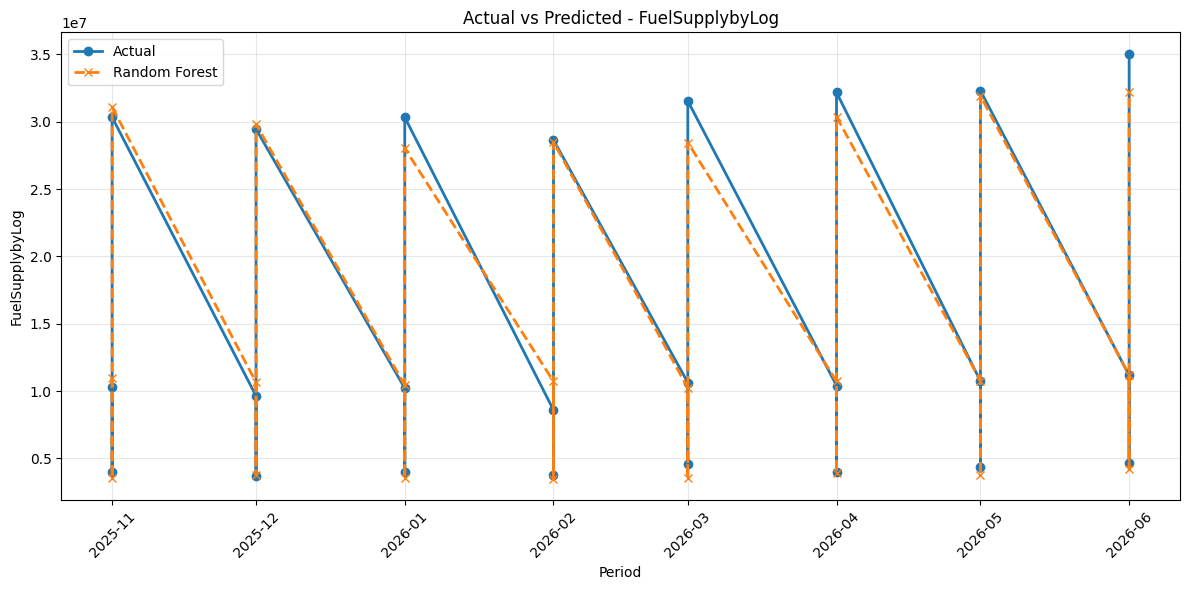

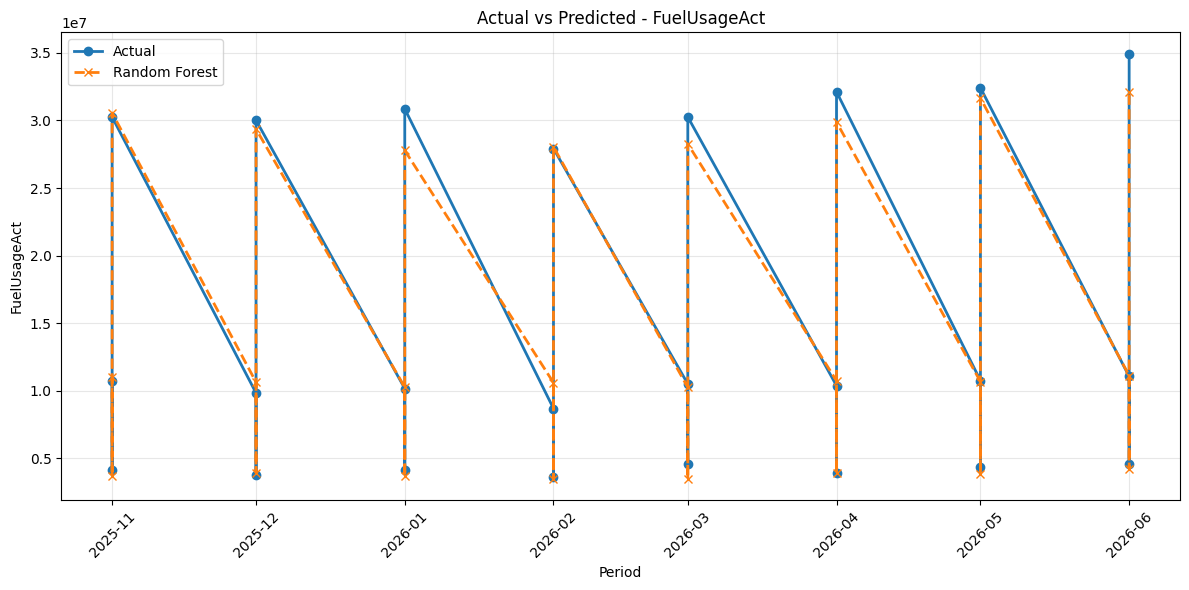

In [13]:
# ============================================================
# 25. ACTUAL VS PREDICTED PLOTS
# ============================================================

for target in target_cols:

    plt.figure(
        figsize=(12, 6)
    )

    plt.plot(
        test["Periode"],
        y_test[target],
        marker="o",
        linewidth=2,
        label="Actual"
    )

    plt.plot(
        test["Periode"],
        predictions[target],
        marker="x",
        linestyle="--",
        linewidth=2,
        label="Random Forest"
    )

    plt.title(
        f"Actual vs Predicted - {target}"
    )

    plt.xlabel(
        "Period"
    )

    plt.ylabel(
        target
    )

    plt.xticks(
        rotation=45
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

# Save Result

In [14]:
# ============================================================
# 26. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "RandomForest_Model_Results.csv",
    index=False
)

prediction_df.to_csv(
    "RandomForest_Predictions.csv",
    index=False
)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print(
    "\nSaved files:"
)

print(
    "1. RandomForest_Model_Results.csv"
)

print(
    "2. RandomForest_Predictions.csv"
)


DONE

Saved files:
1. RandomForest_Model_Results.csv
2. RandomForest_Predictions.csv


### Melakukan Prediksi Baru (proses inference)
Berikut adalah contoh cara menggunakan model untuk memprediksi data baru.

In [15]:
import joblib
import pandas as pd

# ============================================================
# 1. SAVE MODELS AND ARTIFACTS
# ============================================================
# Save the models for each target
for target, model in models.items():
    joblib.dump(model, f"rf_model_{target}.pkl")

# Save the list of features used during training
joblib.dump(feature_cols, "feature_cols.pkl")

# Save medians for imputation in production/testing
training_medians = X_train[numeric_feature_cols].median().to_dict()
joblib.dump(training_medians, "training_medians.pkl")

print("Models and artifacts saved successfully.")

# ============================================================
# 2. TEST INFERENCE (Simulation)
# ============================================================
# Let's pick a single row from the test set to simulate new data
sample_input = X_test.iloc[[0]]

print("\n--- Testing Inference on a Single Row ---")
for target in target_cols:
    loaded_model = joblib.load(f"rf_model_{target}.pkl")
    prediction = loaded_model.predict(sample_input)
    print(f"Predicted {target}: {prediction[0]:,.2f}")
    print(f"Actual {target}   : {y_test[target].iloc[0]:,.2f}")

Models and artifacts saved successfully.

--- Testing Inference on a Single Row ---
Predicted FuelSupplybyLog: 11,001,773.56
Actual FuelSupplybyLog   : 10,331,881.00
Predicted FuelUsageAct: 10,997,410.75
Actual FuelUsageAct   : 10,754,805.00


# Testing by uploading a test file (only works for Google Colab, if you upload this to Azure notebook adjust the codes accordingly)

In [16]:
# import pandas as pd
# import numpy as np
# import joblib
# from google.colab import files
# import io

# # ============================================================
# # 1. UPLOAD AND LOAD NEW DATA
# # ============================================================
# print("Please upload your testing CSV file:")
# uploaded = files.upload()

# # Get the filename
# file_name = list(uploaded.keys())[0]
# df_new = pd.read_csv(io.BytesIO(uploaded[file_name]))

# # ============================================================
# # 2. LOAD MODELS AND ARTIFACTS
# # ============================================================
# try:
#     feature_cols = joblib.load("feature_cols.pkl")
#     training_medians = joblib.load("training_medians.pkl")
#     model_supply = joblib.load("rf_model_FuelSupplybyLog.pkl")
#     model_usage = joblib.load("rf_model_FuelUsageAct.pkl")
#     print("\nModels and artifacts loaded successfully.")
# except FileNotFoundError:
#     print("\nError: Model files not found. Please ensure you ran the training/saving cell first.")

# # ============================================================
# # 3. PREPROCESSING PIPELINE
# # ============================================================
# # Convert Date
# df_new["Periode"] = pd.to_datetime(df_new["Periode"], errors="coerce")
# df_new = df_new.sort_values(["Periode", "Kontraktor"]).reset_index(drop=True)

# # Calendar Features
# df_new["Year"] = df_new["Periode"].dt.year
# df_new["Month"] = df_new["Periode"].dt.month
# df_new["Quarter"] = df_new["Periode"].dt.quarter
# df_new["Month_sin"] = np.sin(2 * np.pi * df_new["Month"] / 12)
# df_new["Month_cos"] = np.cos(2 * np.pi * df_new["Month"] / 12)

# # Generate Lags and Rolling (Logic must match training)
# lag_targets = ["FuelSupplybyLog", "FuelUsageAct"]
# for target in lag_targets:
#     if target in df_new.columns:
#         for lag in [1, 2, 3]:
#             df_new[f"{target}_lag{lag}"] = df_new.groupby("Kontraktor")[target].shift(lag)
#         df_new[f"{target}_rolling3"] = df_new.groupby("Kontraktor")[target].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
#         df_new[f"{target}_rolling6"] = df_new.groupby("Kontraktor")[target].transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())

# # Dummies for Kontraktor
# df_new = pd.get_dummies(df_new, columns=["Kontraktor"], dtype=int)

# # Ensure all training features exist (add missing contractor columns as 0)
# for col in feature_cols:
#     if col not in df_new.columns:
#         df_new[col] = 0

# # Handle missing values using training medians
# for col, val in training_medians.items():
#     if col in df_new.columns:
#         df_new[col] = df_new[col].fillna(val)

# # ============================================================
# # 4. INFERENCE
# # ============================================================
# X_new = df_new[feature_cols]

# df_new["Pred_FuelSupplybyLog"] = model_supply.predict(X_new)
# df_new["Pred_FuelUsageAct"] = model_usage.predict(X_new)

# print("\n--- Prediction Results ---")
# output_cols = ["Periode"] + [c for c in df_new.columns if c.startswith("Kontraktor_")] + ["Pred_FuelSupplybyLog", "Pred_FuelUsageAct"]
# print(df_new[output_cols].head())

# # Optional: Save results
# df_new.to_csv("uploaded_data_predictions.csv", index=False)
# print("\nFull predictions saved to 'uploaded_data_predictions.csv'")

Please upload your testing CSV file:


Saving TestingData.csv to TestingData.csv

Models and artifacts loaded successfully.

--- Prediction Results ---
     Periode  Kontraktor_BUMA  Kontraktor_PPA  Kontraktor_SIS  \
0 2026-07-01                1               0               0   
1 2026-07-01                0               0               1   
2 2026-08-01                1               0               0   
3 2026-08-01                0               1               0   
4 2026-08-01                0               0               1   

   Pred_FuelSupplybyLog  Pred_FuelUsageAct  
0          1.116340e+07       1.128608e+07  
1          1.721434e+07       1.713880e+07  
2          1.083778e+07       1.083889e+07  
3          7.576531e+06       7.720900e+06  
4          2.413971e+07       2.407495e+07  

Full predictions saved to 'uploaded_data_predictions.csv'
